# Single Record Full Preprocessing – MIT-BIH Arrhythmia Dataset

This notebook performs complete preprocessing for *one* ECG record, including:
- Signal cleaning
- Baseline filtering
- Beat segmentation
- Normalization
- Outlier removal
- Label handling
- Visual checks

Once validated, this logic will be moved into a preprocessing pipeline `.py` script for the entire dataset.


In [5]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../Data/Raw/"
record_id = "100"

record = wfdb.rdrecord(DATA_PATH + record_id)
ann = wfdb.rdann(DATA_PATH + record_id, "atr")

signal = record.p_signal[:,0]     # MLII channel
fs = record.fs                    # 360 Hz

signal.shape, fs


((650000,), 360)

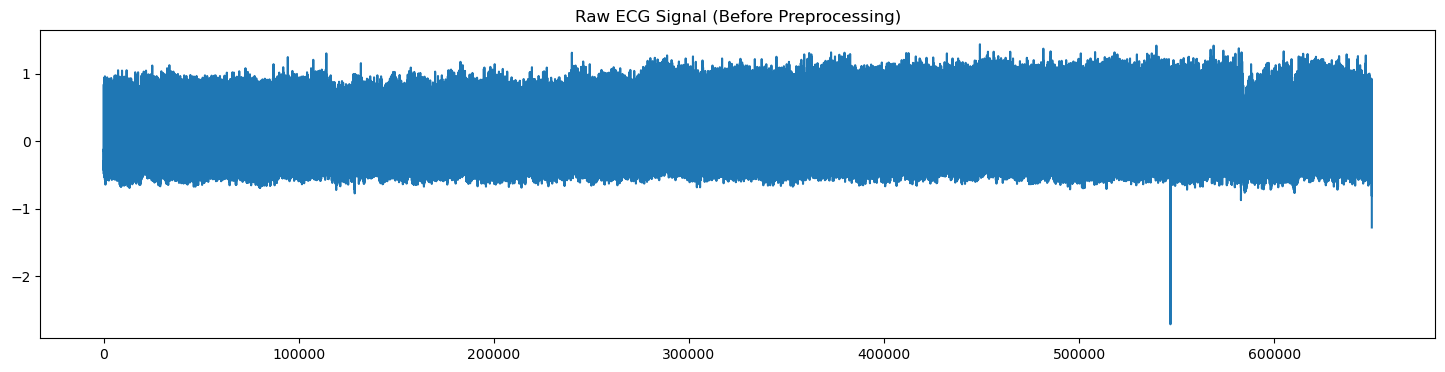

In [7]:
plt.figure(figsize=(18,4))
plt.plot(signal)
plt.title("Raw ECG Signal (Before Preprocessing)")
plt.show()


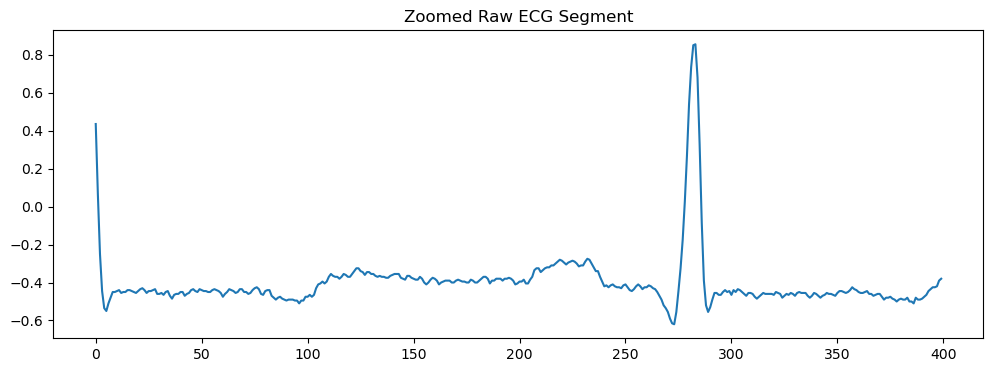

In [9]:
plt.figure(figsize=(12,4))
plt.plot(signal[10000:10400])
plt.title("Zoomed Raw ECG Segment")
plt.show()


### Baseline Wander Removal (High-pass filtering)

In [12]:
from scipy.signal import butter, filtfilt

def highpass_filter(sig, cutoff=0.5, fs=360, order=3):
    b, a = butter(order, cutoff/(fs/2), btype='high')
    return filtfilt(b, a, sig)

hp_filtered = highpass_filter(signal)


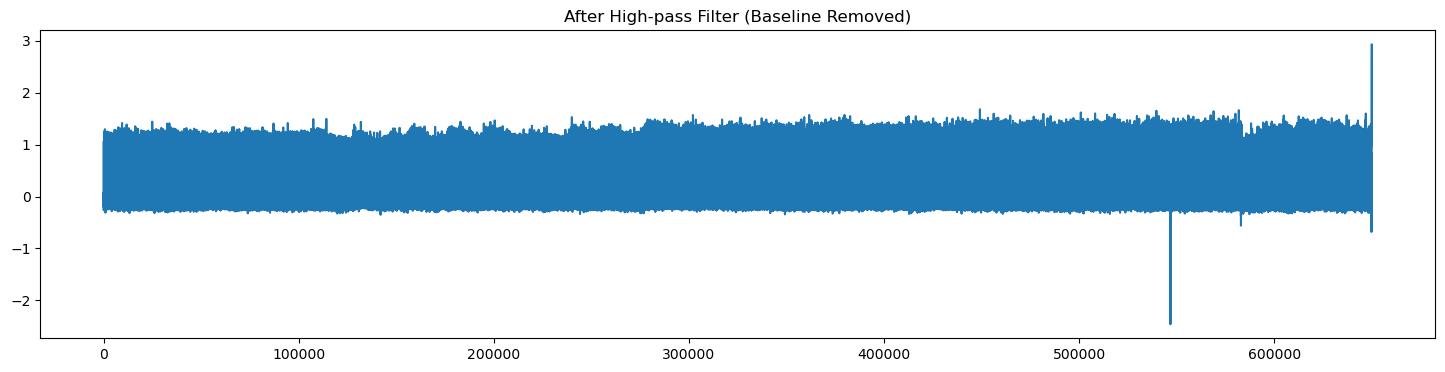

In [14]:
plt.figure(figsize=(18,4))
plt.plot(hp_filtered)
plt.title("After High-pass Filter (Baseline Removed)")
plt.show()


### Bandpass Filtering (0.5–40 Hz)

In [17]:
def bandpass(sig, low=0.5, high=40, fs=360, order=3):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, sig)

filtered = bandpass(signal)


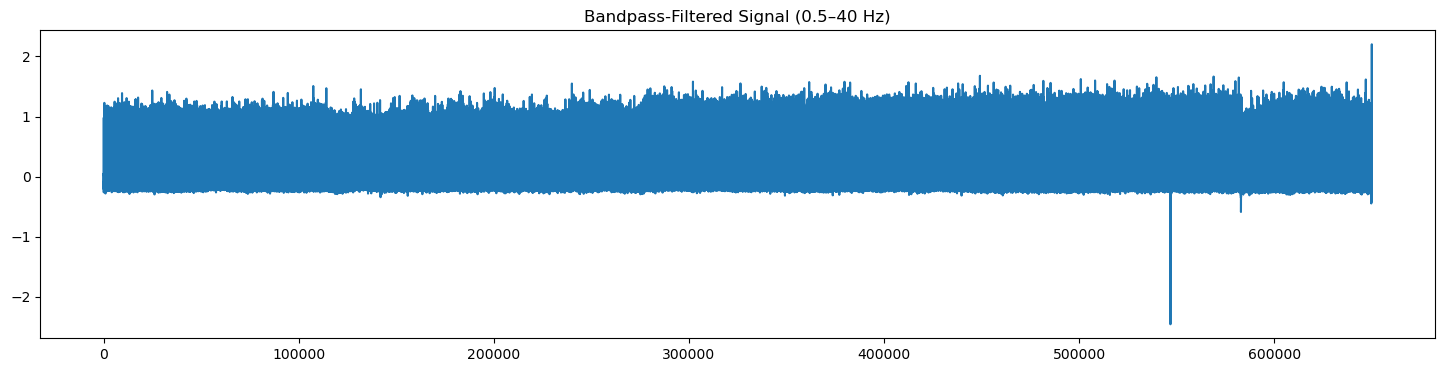

In [19]:
plt.figure(figsize=(18,4))
plt.plot(filtered)
plt.title("Bandpass-Filtered Signal (0.5–40 Hz)")
plt.show()


### R-Peak Extraction Using Annotations

In [22]:
r_peaks = ann.sample
symbols = ann.symbol

len(r_peaks), r_peaks[:10], symbols[:10]


(2274,
 array([  18,   77,  370,  662,  946, 1231, 1515, 1809, 2044, 2402],
       dtype=int64),
 ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N'])

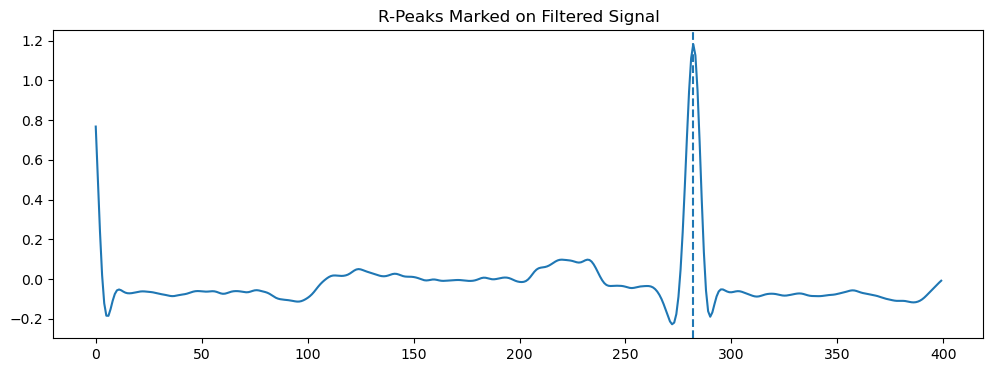

In [24]:
sample_range = (10000, 10400)
subset = filtered[sample_range[0]:sample_range[1]]

plt.figure(figsize=(12,4))
plt.plot(subset)

for r in r_peaks:
    if sample_range[0] < r < sample_range[1]:
        plt.axvline(r - sample_range[0], linestyle='--')

plt.title("R-Peaks Marked on Filtered Signal")
plt.show()


### Heartbeat Segmentation
We extract fixed-length windows around each R-peak:
- window_size = 180 samples left & right (≈ 1 second total)
- Ensures same input dimensionality for deep learning


In [28]:
window = 180
beats = []
labels = []

for i, r in enumerate(r_peaks):
    start, end = r - window, r + window
    if start < 0 or end >= len(filtered):
        continue
    segment = filtered[start:end]
    beats.append(segment)
    labels.append(symbols[i])

beats = np.array(beats)
labels = np.array(labels)
beats.shape, labels[:10]


((2271, 360),
 array(['N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N'], dtype='<U1'))

In [30]:
beats_norm = (beats - beats.mean(axis=1, keepdims=True)) / (
    beats.std(axis=1, keepdims=True) + 1e-8
)


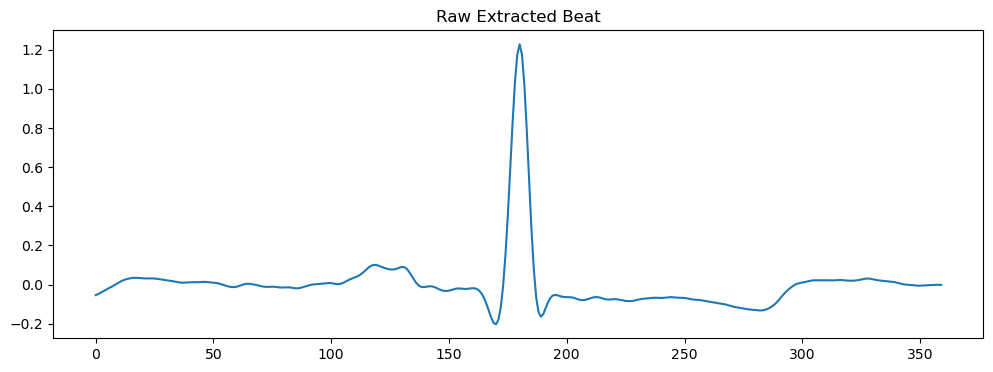

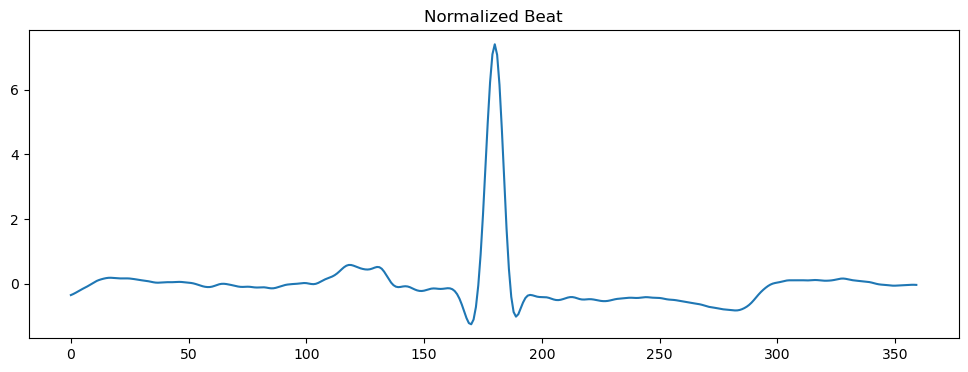

In [32]:
plt.figure(figsize=(12,4))
plt.plot(beats[0])
plt.title("Raw Extracted Beat")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(beats_norm[0])
plt.title("Normalized Beat")
plt.show()


### Outlier Detection & Removal

In [ ]:
valid_idx = []

for i, b in enumerate(beats_norm):
    if np.max(np.abs(b)) < 5:   # threshold
        valid_idx.append(i)

beats_clean = beats_norm[valid_idx]
labels_clean = labels[valid_idx]

beats_clean.shape


### Label Mapping (AAMI Classes)

In [38]:
aami_map = {
    'N':'N', 'L':'N', 'R':'N', 'e':'N', 'j':'N', 'S':'N',
    'V':'V', 'E':'V',
    'A':'S', 'a':'S', 'J':'S',
    'F':'F',
    '/':'Q', 'f':'Q', 'Q':'Q'
}

mapped_labels = np.array([aami_map.get(l, 'Q') for l in labels_clean])


In [40]:
(unique, counts) = np.unique(mapped_labels, return_counts=True)
dict(zip(unique, counts))


{'V': 1}

### Plot Multiple Cleaned & Normalized Beats Per Class

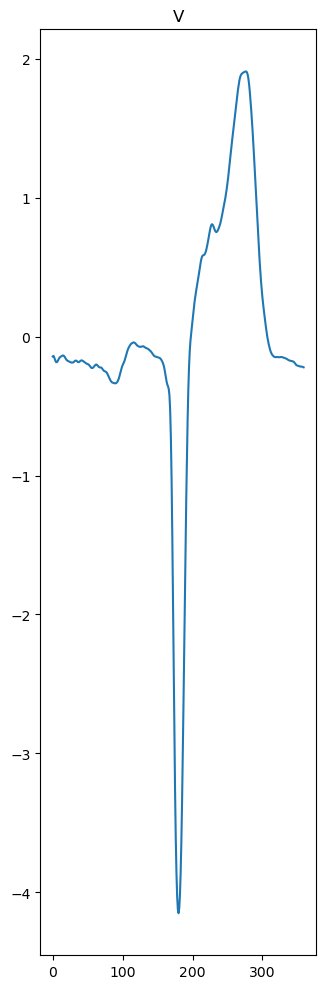

In [43]:
plt.figure(figsize=(15,10))
i = 1
classes = np.unique(mapped_labels)

for cls in classes:
    class_beats = beats_clean[mapped_labels == cls]
    for b in class_beats[:5]:
        plt.subplot(len(classes),5,i)
        plt.plot(b)
        plt.title(cls)
        i+=1

plt.tight_layout()
plt.show()


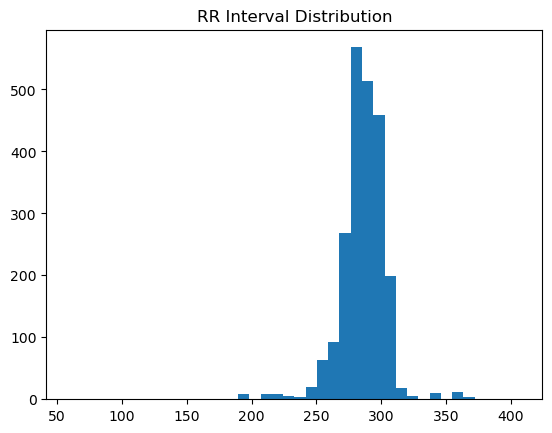

In [45]:
rr_intervals = np.diff(r_peaks)
plt.hist(rr_intervals, bins=40)
plt.title("RR Interval Distribution")
plt.show()


In [49]:
np.save("../Data/Processed/record100_beats.npy", beats_clean)
np.save("../Data/Processed/record100_labels.npy", mapped_labels)


### Preprocessing Summary for Record 100

- Baseline + bandpass filtering applied  
- R-peaks extracted  
- Fixed window segmentation (360 samples)  
- Per-beat normalization  
- Outliers removed  
- Labels mapped to AAMI standard classes  
- Data ready for deep learning  
